In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv(
    'step2_click_sample_labeled_7d.csv',
    parse_dates=['click_date', 'first_click_ts', 'last_click_ts', 'order_time'],
    low_memory=False
)

print(df.shape)
print(df.columns.tolist())
df.head()

(213050, 41)
['user_id', 'sku_id', 'channel', 'click_date', 'first_click_ts', 'last_click_ts', 'click_cnt', 'hour', 'dow', 'is_weekend', 'hour_bucket', 'user_day_total_clicks', 'user_day_distinct_skus', 'user_day_distinct_channels', 'user_sku_click_days_so_far', 'user_sku_clicks_so_far', 'repeat_same_sku_flag', 'same_day_multi_click_flag', 'same_sku_click_share_in_day', 'sku_focus_flag', 'is_plus', 'purchase_power', 'city_level', 'gender', 'age', 'user_level', 'type', 'brand_id', 'any_attr_missing', 'any_attr_placeholder', 'brand_sku_cnt', 'user_sku_key', 'order_time', 'order_id', 'order_gmv', 'order_qty', 'days_to_purchase', 'label_1d', 'label_3d', 'label_7d', 'click_cnt_bucket']


,user_id,sku_id,channel,click_date,first_click_ts,last_click_ts,click_cnt,hour,dow,is_weekend,hour_bucket,user_day_total_clicks,user_day_distinct_skus,user_day_distinct_channels,user_sku_click_days_so_far,user_sku_clicks_so_far,repeat_same_sku_flag,same_day_multi_click_flag,same_sku_click_share_in_day,sku_focus_flag,is_plus,purchase_power,city_level,gender,age,user_level,type,brand_id,any_attr_missing,any_attr_placeholder,brand_sku_cnt,user_sku_key,order_time,order_id,order_gmv,order_qty,days_to_purchase,label_1d,label_3d,label_7d,click_cnt_bucket
0,7a89b29ba5,a0e49f9966,app,2018-02-28,2018-02-28 23:59:01,2018-02-28 23:59:01,1,23.0,2.0,0,late_night,3,2,1,1,1,0,0,0.333333,0,1,2,1,F,26-35,4,1,7cc01be867,0,1,253,7a89b29ba5||a0e49f9966,2018-03-02 10:08:04,79cded2f9d,-1.0,4.0,1.422951,0,1,1,1
1,ba189a22b7,2f268cf558,app,2018-02-28,2018-02-28 23:59:02,2018-02-28 23:59:02,1,23.0,2.0,0,late_night,1,1,1,1,1,0,0,1.000000,1,0,2,4,F,26-35,2,2,603dc9ab6b,0,0,290,ba189a22b7||2f268cf558,NaT,NaN,NaN,NaN,NaN,0,0,0,1
2,e03f8c6d4e,6a0f1004bb,app,2018-02-28,2018-02-28 23:59:02,2018-02-28 23:59:02,1,23.0,2.0,0,late_night,1,1,1,1,1,0,0,1.000000,1,1,2,4,F,26-35,4,1,8368e30fa1,0,0,5,e03f8c6d4e||6a0f1004bb,NaT,NaN,NaN,NaN,NaN,0,0,0,1
3,7093c5f021,861f71f9ad,app,2018-02-28,2018-02-28 23:59:04,2018-02-28 23:59:04,1,23.0,2.0,0,late_night,1,1,1,1,1,0,0,1.000000,1,0,3,1,M,16-25,1,2,dc7e4ae5fc,0,0,419,7093c5f021||861f71f9ad,NaT,NaN,NaN,NaN,NaN,0,0,0,1
4,7492b76bdf,d3e31fdd6e,app,2018-02-28,2018-02-28 23:59:04,2018-02-28 23:59:04,1,23.0,2.0,0,late_night,5,2,1,1,1,0,0,0.200000,0,0,4,4,M,26-35,3,1,99d41501ff,0,0,271,7492b76bdf||d3e31fdd6e,2018-03-01 00:15:48,d23139c202,0.0,1.0,0.011620,1,1,1,1


In [3]:
use_cols = [
    'label_1d',
    'label_3d',
    'label_7d',
    'channel',
    'type',
    'sku_focus_flag',
    'repeat_same_sku_flag',
    'click_cnt',
    'user_day_distinct_skus',
    'user_day_distinct_channels',
    'is_plus',
    'purchase_power',
    'city_level',
    'gender',
    'age'
]

data = df[use_cols].copy()

data = data.dropna(subset=[
    'label_7d',
    'channel',
    'type',
    'sku_focus_flag',
    'click_cnt',
    'user_day_distinct_skus',
    'user_day_distinct_channels'
]).copy()

data['label_7d'] = data['label_7d'].astype(int)
data['label_3d'] = data['label_3d'].astype(int)
data['label_1d'] = data['label_1d'].astype(int)

data['type_name'] = data['type'].map({1: '1P', 2: '3P'})

print(data.shape)
data.head()

(213050, 16)


,label_1d,label_3d,label_7d,channel,type,sku_focus_flag,repeat_same_sku_flag,click_cnt,user_day_distinct_skus,user_day_distinct_channels,is_plus,purchase_power,city_level,gender,age,type_name
0,0,1,1,app,1,0,0,1,2,1,1,2,1,F,26-35,1P
1,0,0,0,app,2,1,0,1,1,1,0,2,4,F,26-35,3P
2,0,0,0,app,1,1,0,1,1,1,1,2,4,F,26-35,1P
3,0,0,0,app,2,1,0,1,1,1,0,3,1,M,16-25,3P
4,1,1,1,app,1,0,0,1,2,1,0,4,4,M,26-35,1P


In [4]:
# 点击次数分桶
data['click_cnt_bucket'] = pd.cut(
    data['click_cnt'],
    bins=[0, 1, 2, 3, 5, 10, 999999],
    labels=['1', '2', '3', '4-5', '6-10', '10+'],
    right=True
)

# 当天浏览SKU数分桶
data['distinct_sku_bucket'] = pd.cut(
    data['user_day_distinct_skus'],
    bins=[0, 2, 5, 10, 20, 999999],
    labels=['1-2', '3-5', '6-10', '11-20', '20+'],
    right=True
)

# 当天使用渠道数分桶
data['distinct_channel_bucket'] = pd.cut(
    data['user_day_distinct_channels'],
    bins=[0, 1, 2, 3, 10],
    labels=['1', '2', '3', '4+'],
    right=True
)

data.head()

,label_1d,label_3d,label_7d,channel,type,sku_focus_flag,repeat_same_sku_flag,click_cnt,user_day_distinct_skus,user_day_distinct_channels,is_plus,purchase_power,city_level,gender,age,type_name,click_cnt_bucket,distinct_sku_bucket,distinct_channel_bucket
0,0,1,1,app,1,0,0,1,2,1,1,2,1,F,26-35,1P,1,1-2,1
1,0,0,0,app,2,1,0,1,1,1,0,2,4,F,26-35,3P,1,1-2,1
2,0,0,0,app,1,1,0,1,1,1,1,2,4,F,26-35,1P,1,1-2,1
3,0,0,0,app,2,1,0,1,1,1,0,3,1,M,16-25,3P,1,1-2,1
4,1,1,1,app,1,0,0,1,2,1,0,4,4,M,26-35,1P,1,1-2,1


In [5]:
# 4.1 聚焦分
data['score_focus'] = np.where(data['sku_focus_flag'] == 1, 3, 0)

# 4.2 SKU广度分
data['score_sku_breadth'] = np.select(
    [
        data['distinct_sku_bucket'] == '1-2',
        data['distinct_sku_bucket'] == '3-5',
        data['distinct_sku_bucket'] == '6-10',
        data['distinct_sku_bucket'].isin(['11-20', '20+'])
    ],
    [3, 2, 1, 0],
    default=0
)

# 4.3 点击强度分
data['score_click_cnt'] = np.select(
    [
        data['click_cnt_bucket'] == '1',
        data['click_cnt_bucket'] == '2',
        data['click_cnt_bucket'] == '3',
        data['click_cnt_bucket'] == '4-5',
        data['click_cnt_bucket'] == '6-10',
        data['click_cnt_bucket'] == '10+'
    ],
    [0, 1, 2, 2, 2, 1],
    default=0
)

# 4.4 渠道切换分
data['score_channel_mix'] = np.select(
    [
        data['distinct_channel_bucket'] == '1',
        data['distinct_channel_bucket'] == '2',
        data['distinct_channel_bucket'].isin(['3', '4+'])
    ],
    [1, 0, -1],
    default=0
)

# 规则总分
data['rule_score'] = (
    data['score_focus']
    + data['score_sku_breadth']
    + data['score_click_cnt']
    + data['score_channel_mix']
)

data[['score_focus', 'score_sku_breadth', 'score_click_cnt', 'score_channel_mix', 'rule_score']].head()

,score_focus,score_sku_breadth,score_click_cnt,score_channel_mix,rule_score
0,0,3,0,1,4
1,3,3,0,1,7
2,3,3,0,1,7
3,3,3,0,1,7
4,0,3,0,1,4


In [6]:
data['rule_intent_tier'] = pd.cut(
    data['rule_score'],
    bins=[-999, 3, 5, 999],
    labels=['低意愿点击', '中意愿点击', '高意愿点击']
)

data[['rule_score', 'rule_intent_tier']].head()

,rule_score,rule_intent_tier
0,4,中意愿点击
1,7,高意愿点击
2,7,高意愿点击
3,7,高意愿点击
4,4,中意愿点击


In [7]:
rule_score_dist = (
    data['rule_score']
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)
rule_score_dist.columns = ['rule_score', 'samples']

display(rule_score_dist)

,rule_score,samples
0,-1,782
1,0,3108
2,1,30263
3,2,41109
4,3,52054
5,4,27481
6,5,9971
7,6,1688
8,7,20994
9,8,14603


In [8]:
rule_tier_summary = (
    data
    .groupby('rule_intent_tier', as_index=False)
    .agg(
        samples=('label_7d', 'size'),
        conv_1d=('label_1d', 'mean'),
        conv_3d=('label_3d', 'mean'),
        conv_7d=('label_7d', 'mean'),
        avg_click_cnt=('click_cnt', 'mean'),
        avg_distinct_skus=('user_day_distinct_skus', 'mean'),
        avg_distinct_channels=('user_day_distinct_channels', 'mean'),
        focus_rate=('sku_focus_flag', 'mean')
    )
)

display(rule_tier_summary)

,rule_intent_tier,samples,conv_1d,conv_3d,conv_7d,avg_click_cnt,avg_distinct_skus,avg_distinct_channels,focus_rate
0,低意愿点击,127316,0.046255,0.053450,0.059914,1.816017,11.732343,1.122490,0.000000
1,中意愿点击,37452,0.143864,0.164290,0.180738,3.346550,4.848126,1.024778,0.001976
2,高意愿点击,48282,0.245682,0.282486,0.316412,3.348184,1.831614,1.022410,0.984963


In [9]:
rule_score_summary = (
    data
    .groupby('rule_score', as_index=False)
    .agg(
        samples=('label_7d', 'size'),
        conv_1d=('label_1d', 'mean'),
        conv_3d=('label_3d', 'mean'),
        conv_7d=('label_7d', 'mean')
    )
    .sort_values('rule_score')
)

display(rule_score_summary)

,rule_score,samples,conv_1d,conv_3d,conv_7d
0,-1,782,0.033248,0.035806,0.039642
1,0,3108,0.028314,0.031853,0.035714
2,1,30263,0.014275,0.017150,0.019364
3,2,41109,0.038288,0.044491,0.049916
4,3,52054,0.072406,0.083183,0.093134
5,4,27481,0.132419,0.150395,0.165423
6,5,9971,0.175409,0.202588,0.222947
7,6,1688,0.278436,0.308649,0.325829
8,7,20994,0.188292,0.219825,0.252548
9,8,14603,0.276519,0.315278,0.349517


In [10]:
rule_tier_channel = pd.crosstab(
    data['channel'],
    data['rule_intent_tier'],
    normalize='columns'
).reset_index()

display(rule_tier_channel)

rule_intent_tier,channel,低意愿点击,中意愿点击,高意愿点击
0,app,0.818829,0.869620,0.858249
1,mobile,0.017940,0.014766,0.019821
2,others,0.015568,0.005367,0.007394
3,pc,0.060456,0.033563,0.037716
4,wechat,0.087208,0.076685,0.076820


In [11]:
rule_tier_channel_cnt = pd.crosstab(
    data['channel'],
    data['rule_intent_tier']
).reset_index()

rule_tier_type_cnt = pd.crosstab(
    data['type_name'],
    data['rule_intent_tier']
).reset_index()

display(rule_tier_channel_cnt)
display(rule_tier_type_cnt)

rule_intent_tier,channel,低意愿点击,中意愿点击,高意愿点击
0,app,104250,32569,41438
1,mobile,2284,553,957
2,others,1982,201,357
3,pc,7697,1257,1821
4,wechat,11103,2872,3709


rule_intent_tier,type_name,低意愿点击,中意愿点击,高意愿点击
0,1P,73932,25696,33308
1,3P,53384,11756,14974


In [12]:
rule_tier_type = pd.crosstab(
    data['type_name'],
    data['rule_intent_tier'],
    normalize='columns'
).reset_index()

display(rule_tier_type)

rule_intent_tier,type_name,低意愿点击,中意愿点击,高意愿点击
0,1P,0.580697,0.686105,0.689864
1,3P,0.419303,0.313895,0.310136


In [13]:
target = 'label_7d'

feature_cols = [
    'channel',
    'type',
    'sku_focus_flag',
    'repeat_same_sku_flag',
    'click_cnt',
    'user_day_distinct_skus',
    'user_day_distinct_channels',
    'is_plus',
    'purchase_power',
    'city_level',
    'gender',
    'age',
    'rule_score'   # 把规则分也作为一个特征放进去（可选）
]

model_data = data[feature_cols + [target]].copy()
model_data = model_data.dropna().copy()

X = model_data[feature_cols]
y = model_data[target].astype(int)

print(X.shape, y.shape)
print('7天转化率:', y.mean())

(213050, 13) (213050,)
7天转化率: 0.13928185871861065


In [14]:
numeric_features = [
    'click_cnt',
    'user_day_distinct_skus',
    'user_day_distinct_channels',
    'rule_score'
]

categorical_features = [
    'channel',
    'type',
    'sku_focus_flag',
    'repeat_same_sku_flag',
    'is_plus',
    'purchase_power',
    'city_level',
    'gender',
    'age'
]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print('train pos rate:', y_train.mean())
print('test pos rate :', y_test.mean())

(149135, 13) (63915, 13)
train pos rate: 0.1392831997854293
test pos rate : 0.13927872956270046


In [16]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

logit_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('clf', LogisticRegression(max_iter=1000))
])

logit_model.fit(X_train, y_train)

print('Logistic Regression 训练完成')

Logistic Regression 训练完成


In [17]:
y_test_prob = logit_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_test_prob)
ap = average_precision_score(y_test, y_test_prob)
brier = brier_score_loss(y_test, y_test_prob)

print('AUC              :', round(auc, 4))
print('Average Precision:', round(ap, 4))
print('Brier Score      :', round(brier, 4))

AUC              : 0.7782
Average Precision: 0.3348
Brier Score      : 0.1055


In [18]:
score_test = pd.DataFrame({
    'y_true': y_test.values,
    'pred_prob_7d': y_test_prob
}).sort_values('pred_prob_7d', ascending=False).reset_index(drop=True)

score_test['rank_pct'] = (score_test.index + 1) / len(score_test)
score_test['decile'] = np.ceil(score_test['rank_pct'] * 10).astype(int)

decile_summary = (
    score_test
    .groupby('decile', as_index=False)
    .agg(
        samples=('y_true', 'size'),
        conv_7d=('y_true', 'mean'),
        avg_pred_prob=('pred_prob_7d', 'mean')
    )
)

overall_rate = score_test['y_true'].mean()
decile_summary['lift_vs_overall'] = decile_summary['conv_7d'] / overall_rate

display(decile_summary)
print('Overall conv_7d:', round(overall_rate, 4))

,decile,samples,conv_7d,avg_pred_prob,lift_vs_overall
0,1,6391,0.391488,0.439367,2.810824
1,2,6392,0.299437,0.268729,2.149910
2,3,6391,0.218119,0.192836,1.566063
3,4,6392,0.155038,0.144044,1.113146
4,5,6391,0.113128,0.102777,0.812241
5,6,6392,0.087922,0.083091,0.631269
6,7,6391,0.054295,0.063326,0.389831
7,8,6392,0.042710,0.049074,0.306649
8,9,6391,0.021906,0.034078,0.157280
9,10,6392,0.008761,0.019672,0.062902


Overall conv_7d: 0.1393


In [19]:
data_scored = data.copy()

X_all = data_scored[feature_cols].copy()
data_scored['pred_prob_7d'] = logit_model.predict_proba(X_all)[:, 1]

# 定义模型版 Top10% 高意愿点击
threshold_top10 = data_scored['pred_prob_7d'].quantile(0.90)
data_scored['pred_top10_flag'] = (data_scored['pred_prob_7d'] >= threshold_top10).astype(int)

data_scored[['pred_prob_7d', 'pred_top10_flag']].head()

,pred_prob_7d,pred_top10_flag
0,0.153005,0
1,0.169737,0
2,0.216355,0
3,0.175364,0
4,0.138644,0


In [20]:
pred_pool_summary = (
    data_scored
    .groupby('pred_top10_flag', as_index=False)
    .agg(
        samples=('label_7d', 'size'),
        conv_1d=('label_1d', 'mean'),
        conv_3d=('label_3d', 'mean'),
        conv_7d=('label_7d', 'mean'),
        avg_pred_prob=('pred_prob_7d', 'mean'),
        avg_click_cnt=('click_cnt', 'mean'),
        avg_distinct_skus=('user_day_distinct_skus', 'mean'),
        avg_distinct_channels=('user_day_distinct_channels', 'mean'),
        focus_rate=('sku_focus_flag', 'mean')
    )
)

display(pred_pool_summary)

,pred_top10_flag,samples,conv_1d,conv_3d,conv_7d,avg_pred_prob,avg_click_cnt,avg_distinct_skus,avg_distinct_channels,focus_rate
0,0,191735,0.085493,0.098949,0.111065,0.106253,2.098714,8.962459,1.083104,0.143646
1,1,21315,0.316538,0.357729,0.393103,0.437922,5.432935,2.125452,1.078395,0.942435


In [21]:
rule_vs_model = pd.crosstab(
    data_scored['rule_intent_tier'],
    data_scored['pred_top10_flag'],
    normalize='index'
).reset_index()

display(rule_vs_model)

pred_top10_flag,rule_intent_tier,0,1
0,低意愿点击,0.997832,0.002168
1,中意愿点击,0.981123,0.018877
2,高意愿点击,0.578891,0.421109


In [22]:
rule_vs_model_cnt = pd.crosstab(
    data_scored['rule_intent_tier'],
    data_scored['pred_top10_flag']
).reset_index()

display(rule_vs_model_cnt)

pred_top10_flag,rule_intent_tier,0,1
0,低意愿点击,127040,276
1,中意愿点击,36745,707
2,高意愿点击,27950,20332


In [23]:
pred_pool_channel = pd.crosstab(
    data_scored['channel'],
    data_scored['pred_top10_flag'],
    normalize='columns'
).reset_index()

pred_pool_type = pd.crosstab(
    data_scored['type_name'],
    data_scored['pred_top10_flag'],
    normalize='columns'
).reset_index()

display(pred_pool_channel)
display(pred_pool_type)

pred_top10_flag,channel,0,1
0,app,0.841542,0.793057
1,mobile,0.014953,0.043490
2,others,0.011704,0.013887
3,pc,0.047628,0.077082
4,wechat,0.084173,0.072484


pred_top10_flag,type_name,0,1
0,1P,0.602728,0.815013
1,3P,0.397272,0.184987


In [24]:
feature_names = logit_model.named_steps['preprocess'].get_feature_names_out()
coef = logit_model.named_steps['clf'].coef_[0]

coef_table = pd.DataFrame({
    'feature': feature_names,
    'coef': coef
})

coef_table['odds_ratio'] = np.exp(coef_table['coef'])

coef_table_pos = coef_table.sort_values('coef', ascending=False)
coef_table_neg = coef_table.sort_values('coef', ascending=True)

print('正向最强特征：')
display(coef_table_pos.head(20))

print('负向最强特征：')
display(coef_table_neg.head(20))

正向最强特征：


,feature,coef,odds_ratio
3,num__rule_score,1.172338,3.229533
2,num__user_day_distinct_channels,0.278222,1.320779
0,num__click_cnt,0.205216,1.227790
5,cat__channel_mobile,0.181243,1.198707
11,cat__sku_focus_flag_0,0.143413,1.154207
7,cat__channel_pc,0.093872,1.098419
22,cat__purchase_power_5,0.004022,1.004030
24,cat__city_level_1,0.000984,1.000985
36,cat__age_<=15,-0.002648,0.997355
34,cat__age_36-45,-0.033037,0.967502


负向最强特征：


,feature,coef,odds_ratio
12,cat__sku_focus_flag_1,-0.735386,0.479320
14,cat__repeat_same_sku_flag_1,-0.544166,0.580326
10,cat__type_2,-0.467672,0.626459
4,cat__channel_app,-0.445127,0.640743
8,cat__channel_wechat,-0.342447,0.710031
16,cat__is_plus_1,-0.317441,0.728009
15,cat__is_plus_0,-0.274531,0.759928
38,cat__age_U,-0.214139,0.807237
30,cat__gender_M,-0.209672,0.810850
31,cat__gender_U,-0.199228,0.819363


,group,conv_7d
0,规则高意愿点击,0.316412
1,模型Top10%高意愿点击,0.393103
2,总体,0.139282


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

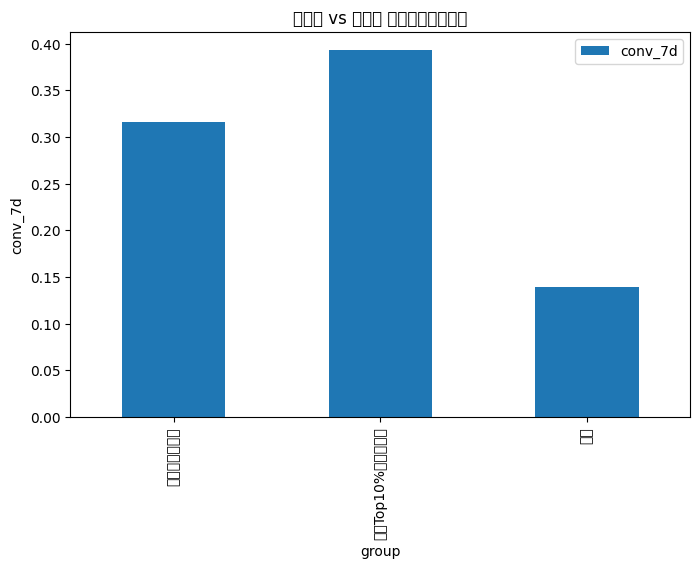

In [26]:
compare_pool = pd.DataFrame({
    'group': ['规则高意愿点击', '模型Top10%高意愿点击', '总体'],
    'conv_7d': [
        data_scored.loc[data_scored['rule_intent_tier'] == '高意愿点击', 'label_7d'].mean(),
        data_scored.loc[data_scored['pred_top10_flag'] == 1, 'label_7d'].mean(),
        data_scored['label_7d'].mean()
    ]
})

display(compare_pool)

compare_pool.plot(
    x='group',
    y='conv_7d',
    kind='bar',
    figsize=(8, 5)
)
plt.title('规则版 vs 模型版 高意愿点击池对比')
plt.ylabel('conv_7d')
plt.show()

In [27]:
rule_score_dist.to_csv('rule_score_dist.csv', index=False)
rule_tier_summary.to_csv('rule_tier_summary.csv', index=False)
rule_score_summary.to_csv('rule_score_summary.csv', index=False)
rule_tier_channel.to_csv('rule_tier_channel.csv', index=False)
rule_tier_type.to_csv('rule_tier_type.csv', index=False)
rule_tier_channel_cnt.to_csv('rule_tier_channel_cnt.csv', index=False)
rule_tier_type_cnt.to_csv('rule_tier_type_cnt.csv', index=False)

decile_summary.to_csv('decile_summary.csv', index=False)
pred_pool_summary.to_csv('pred_pool_summary.csv', index=False)
rule_vs_model.to_csv('rule_vs_model.csv', index=False)
rule_vs_model_cnt.to_csv('rule_vs_model_cnt.csv', index=False)
pred_pool_channel.to_csv('pred_pool_channel.csv', index=False)
pred_pool_type.to_csv('pred_pool_type.csv', index=False)

coef_table.to_csv('logit_coef_table.csv', index=False)
data_scored.to_csv('step4_scored_click_samples.csv', index=False)

print('规则分层 + 预测模型结果已全部导出。')

规则分层 + 预测模型结果已全部导出。
